#Contents

1. Import Libraries and Data

Create Total Runs column

Create subset

Plot subset

2. Time Series Analysis: Decomposition

Split data into months

3. Test for stationaryity

4. Test for Autocorrelation

5. Making Stationary - Differencing

Second round of differencing

## Bonus Task: Time Series Forecasting

Step 1: Confirm your data setup and stationarity

Step 2: Train/Test Split and ARIMA Fitting

Step 2B: Fit the ARIMA model

Step 2C: Use ACF and PACF to choose p and q

Step 2D: Choose ARIMA parameters

Step 2E: Fit the ARIMA model with chosen parameters

Step 3: Forecast and Compare to Test Data

Step 4: Invert Differencing to Return to Original Scale

Step 5: Resolve Non-Unique Timestamps

Step 6: Rebuild Forecast in Original Scale

Step 7: Plot Forecast vs Original Series

Fixing with a safer inversion strategy

Plot the corrected forecast

Step 8: Let ARIMA handle differencing internally

Plot forecast vs actual

Step 9: Add Confidence Intervals to Forecast Plot

Plot with shaded error bands


## 1. Import Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import warnings


warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')

In [2]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Import data

df = pd.read_csv('/content/drive/MyDrive/test_Matches_Data_Clean_Post 1900.csv')

In [4]:
df.head()

,Match ID,Match Name,Start Date,End Date,Team 1,Innings 1 Team 1 Runs,Innings 1 Team 1 Wickets,Innings 1 Team 1 Extras,Innings 2 Team 1 Runs,Innings 2 Team 1 Wickets,...,Innings 2 Team 2 Runs,Innings 2 Team 2 Wickets,Innings 2 Team 2 Extras,Venue,City,Country,Toss Winner,Toss Winner Choice,Winner,Result
0,62387,Australia Vs South Africa,27/05/1912,28/05/1912,Australia,448,10,24,NaN,NaN,...,95.0,10.0,9.0,Old Trafford,Manchester,England,Australia,bat,Australia,Australia won by an innings and 88 runs
1,62388,England Vs South Africa,10/06/1912,12/06/1912,South Africa,58,10,17,217.0,10.0,...,NaN,NaN,NaN,Lord's,London,England,South Africa,bat,England,England won by an innings and 62 runs
2,62389,England Vs Australia,24/06/1912,26/06/1912,England,310,7,22,NaN,NaN,...,NaN,NaN,NaN,Lord's,London,England,England,bat,NaN,Match drawn
3,62390,England Vs South Africa,08/07/1912,10/07/1912,England,242,10,14,238.0,10.0,...,159.0,10.0,11.0,Headingley,Leeds,England,England,bat,England,England won by 174 runs
4,62391,Australia Vs South Africa,15/07/1912,17/07/1912,South Africa,263,10,29,173.0,10.0,...,48.0,0.0,1.0,Lord's,London,England,South Africa,bat,Australia,Australia won by 10 wickets


In [5]:
df.shape

(2473, 25)

In [6]:
#Going to work with one column, and that's going to be a new 'Total Runs' Column

df['Total Runs'] = df['Innings 1 Team 1 Runs']+df['Innings 1 Team 2 Runs']+df['Innings 2 Team 1 Runs']+df['Innings 2 Team 2 Runs']

In [7]:
df.head()

,Match ID,Match Name,Start Date,End Date,Team 1,Innings 1 Team 1 Runs,Innings 1 Team 1 Wickets,Innings 1 Team 1 Extras,Innings 2 Team 1 Runs,Innings 2 Team 1 Wickets,...,Innings 2 Team 2 Wickets,Innings 2 Team 2 Extras,Venue,City,Country,Toss Winner,Toss Winner Choice,Winner,Result,Total Runs
0,62387,Australia Vs South Africa,27/05/1912,28/05/1912,Australia,448,10,24,NaN,NaN,...,10.0,9.0,Old Trafford,Manchester,England,Australia,bat,Australia,Australia won by an innings and 88 runs,NaN
1,62388,England Vs South Africa,10/06/1912,12/06/1912,South Africa,58,10,17,217.0,10.0,...,NaN,NaN,Lord's,London,England,South Africa,bat,England,England won by an innings and 62 runs,NaN
2,62389,England Vs Australia,24/06/1912,26/06/1912,England,310,7,22,NaN,NaN,...,NaN,NaN,Lord's,London,England,England,bat,NaN,Match drawn,NaN
3,62390,England Vs South Africa,08/07/1912,10/07/1912,England,242,10,14,238.0,10.0,...,10.0,11.0,Headingley,Leeds,England,England,bat,England,England won by 174 runs,786.0
4,62391,Australia Vs South Africa,15/07/1912,17/07/1912,South Africa,263,10,29,173.0,10.0,...,0.0,1.0,Lord's,London,England,South Africa,bat,Australia,Australia won by 10 wickets,874.0


In [8]:
#Not what I wanted- it's not creating a total, when there are any NaN values

#Replace any Nan values with 0

df['Innings 1 Team 1 Runs'] = df['Innings 1 Team 1 Runs'].fillna(0)
df['Innings 1 Team 2 Runs'] = df['Innings 1 Team 2 Runs'].fillna(0)
df['Innings 2 Team 1 Runs'] = df['Innings 2 Team 1 Runs'].fillna(0)
df['Innings 2 Team 2 Runs'] = df['Innings 2 Team 2 Runs'].fillna(0)

In [9]:
# Check for missing values

df.isnull().sum()

,0
Match ID,0
Match Name,0
Start Date,0
End Date,0
Team 1,0
Innings 1 Team 1 Runs,0
Innings 1 Team 1 Wickets,0
Innings 1 Team 1 Extras,0
Innings 2 Team 1 Runs,0
Innings 2 Team 1 Wickets,317


Create Total Runs column

In [10]:
df['Total Runs'] = df['Innings 1 Team 1 Runs']+df['Innings 1 Team 2 Runs']+df['Innings 2 Team 1 Runs']+df['Innings 2 Team 2 Runs']

In [11]:
df.head()

,Match ID,Match Name,Start Date,End Date,Team 1,Innings 1 Team 1 Runs,Innings 1 Team 1 Wickets,Innings 1 Team 1 Extras,Innings 2 Team 1 Runs,Innings 2 Team 1 Wickets,...,Innings 2 Team 2 Wickets,Innings 2 Team 2 Extras,Venue,City,Country,Toss Winner,Toss Winner Choice,Winner,Result,Total Runs
0,62387,Australia Vs South Africa,27/05/1912,28/05/1912,Australia,448,10,24,0.0,NaN,...,10.0,9.0,Old Trafford,Manchester,England,Australia,bat,Australia,Australia won by an innings and 88 runs,808.0
1,62388,England Vs South Africa,10/06/1912,12/06/1912,South Africa,58,10,17,217.0,10.0,...,NaN,NaN,Lord's,London,England,South Africa,bat,England,England won by an innings and 62 runs,612.0
2,62389,England Vs Australia,24/06/1912,26/06/1912,England,310,7,22,0.0,NaN,...,NaN,NaN,Lord's,London,England,England,bat,NaN,Match drawn,592.0
3,62390,England Vs South Africa,08/07/1912,10/07/1912,England,242,10,14,238.0,10.0,...,10.0,11.0,Headingley,Leeds,England,England,bat,England,England won by 174 runs,786.0
4,62391,Australia Vs South Africa,15/07/1912,17/07/1912,South Africa,263,10,29,173.0,10.0,...,0.0,1.0,Lord's,London,England,South Africa,bat,Australia,Australia won by 10 wickets,874.0


Create subset

Now I have a column of total runs for the match, I just want to use this asnd the data column

In [12]:
#Create a subset

df_sub = df[['Start Date', 'Total Runs']]

In [13]:
df_sub.head()

,Start Date,Total Runs
0,27/05/1912,808.0
1,10/06/1912,612.0
2,24/06/1912,592.0
3,08/07/1912,786.0
4,15/07/1912,874.0


In [14]:
#Set the date column as the index

#Then re-set the date BACk as the index

from datetime import datetime

df_sub['datetime'] = pd.to_datetime(df_sub['Start Date']) #create a datetime column from 'Start Date'
df_sub = df_sub.set_index('datetime') #set the index to the new datetime column
df_sub.drop('Start Date', axis=1, inplace=True) #drop the original 'Start Date' column
df_sub.head()

,Total Runs
datetime,
1912-05-27,808.0
1912-06-10,612.0
1912-06-24,592.0
1912-07-08,786.0
1912-07-15,874.0


Plot subset

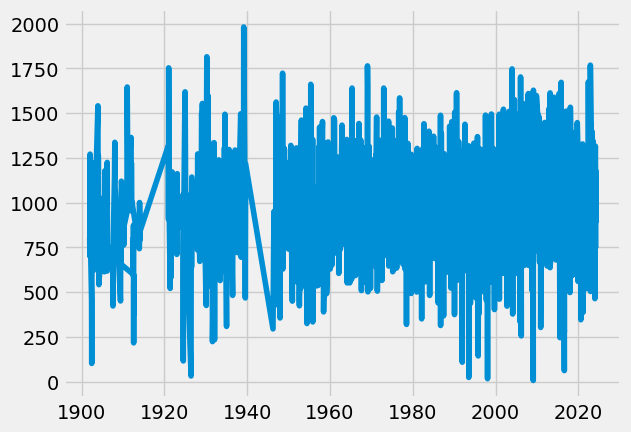

In [15]:
#plot this data with matplotlib

plt.plot(df_sub)
plt.show()

It *looks* fairly stationary (which surprises me tbh) - but will use checks to test

In [16]:
# Check for missing values

df_sub.isnull().sum()

,0
Total Runs,0


In [17]:
#check for dups

df_sub.duplicated().sum()

np.int64(1530)

I think that is what is happening, is that with the date as the index, there is only one column - totals - and in that the same score will have been made many times. I'll do another test.

In [18]:
df_sub2 = df[['Start Date', 'Total Runs']]

In [19]:
#check for dups

df_sub2.duplicated().sum()

np.int64(0)

So, there aren't actually any duplicates - we can carry on!

# 2. Time Series Analysis: Decomposition

In [20]:
df_sub_monthly = df_sub['Total Runs'].resample('MS').sum()

# Decompose the time series using an additive model

#this splits the series inot three components: underlying trend, seasonaility, and the noise (plus the original data)

decomposition = sm.tsa.seasonal_decompose(df_sub_monthly, model='additive', period=12)

Split data into months

In contrast to the quarterly data I used before, need to treat the data to split into months

In [21]:
from pylab import rcParams # This will define a fixed size for all special charts.

rcParams['figure.figsize'] = 18, 7

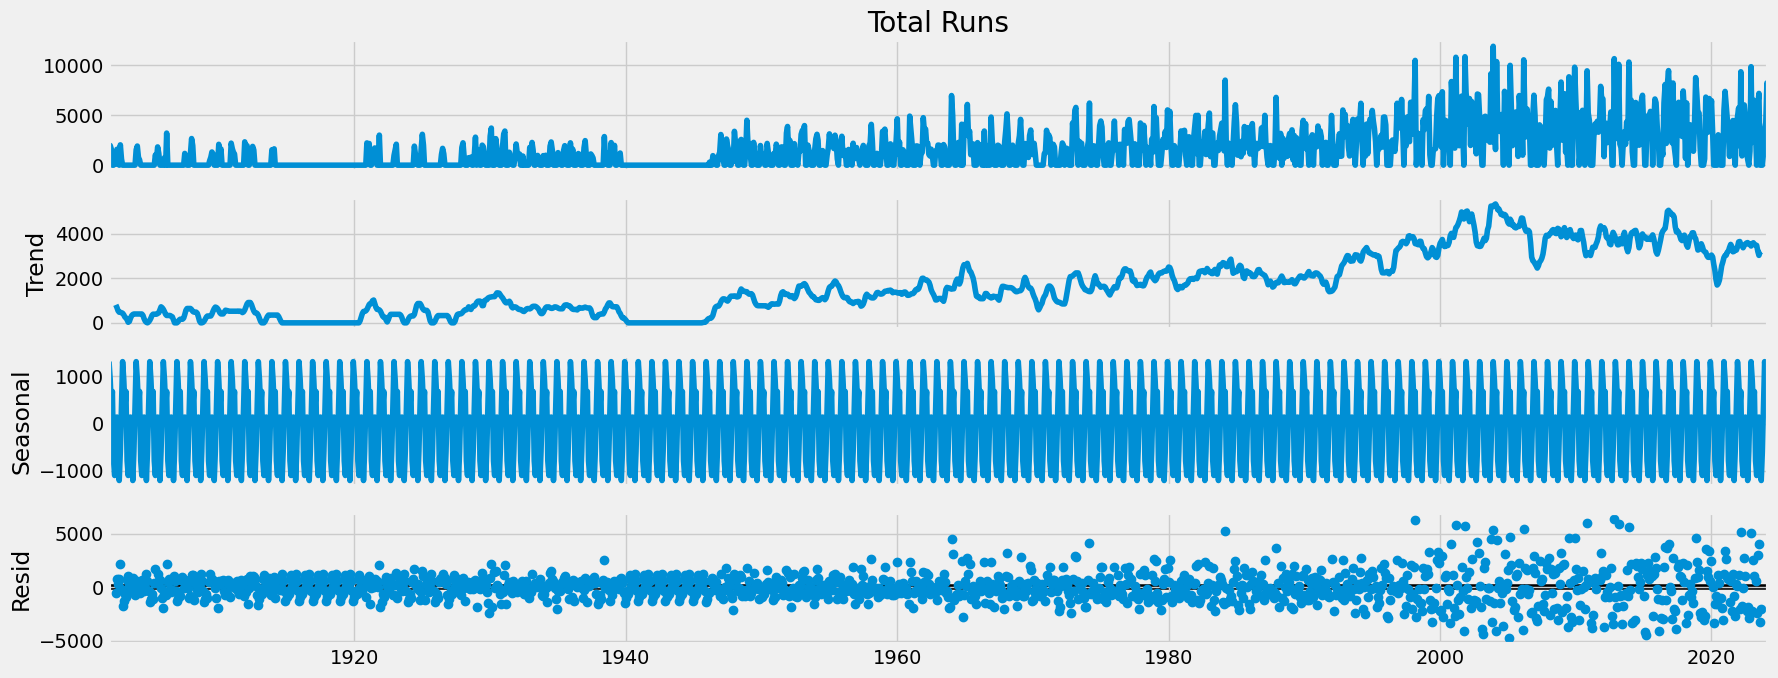

In [22]:
decomposition.plot()
plt.show()

# 3. Test for stationaryity

In [23]:
# The adfuller() function will import from the model from statsmodels for the test; however, running it will only return
# an array of numbers. This is why you need to also define a function that prints the correct output from that array.

from statsmodels.tsa.stattools import adfuller # Import the adfuller() function

def dickey_fuller(timeseries): # Define the function
    # Perform the Dickey-Fuller test:
    print ('Dickey-Fuller Stationarity test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in test[4].items():
       result['Critical Value (%s)'%key] = value
    print (result)

# Apply the test using the function on the time series
dickey_fuller(df_sub_monthly)

Dickey-Fuller Stationarity test:
Test Statistic                   -1.345641
p-value                           0.608042
Number of Lags Used              24.000000
Number of Observations Used    1443.000000
Critical Value (1%)              -3.434890
Critical Value (5%)              -2.863545
Critical Value (10%)             -2.567837
dtype: float64


Interpreting these results:

This is the Dickey-Fuller test, which is a statistical test that checks for the presence of a unit root.

A unit root is any random jump that can’t be explained by variation in the data—in other words, a jump that’s not constant - would make the time series non-stationary


The null hypothesis in this case would be the presence of a unit root i.e. I want to *disprove* that there’s a unit root - which would mean the data is stationary.

The alternative hypothesis is that there’s no unit root. If I can’t rule out the null hypothesis, the data is non-stationary.



Disprove the null = no unit root = stationary data = can proceed with forecast





    Test statistic larger than critical value = can’t reject null hypothesis
    Test statistic smaller than critical value = can reject null hypothesis





In this case: Test Statistic = -1.35 > Critical Value 5% = -2.86

SO: We can't reject the null hypothesis

SO: There is a unit root

SO: the data is non-stationary

Which goes against what we saw visually - so proves the value of the test!


# 4. Test for Autocorrelation

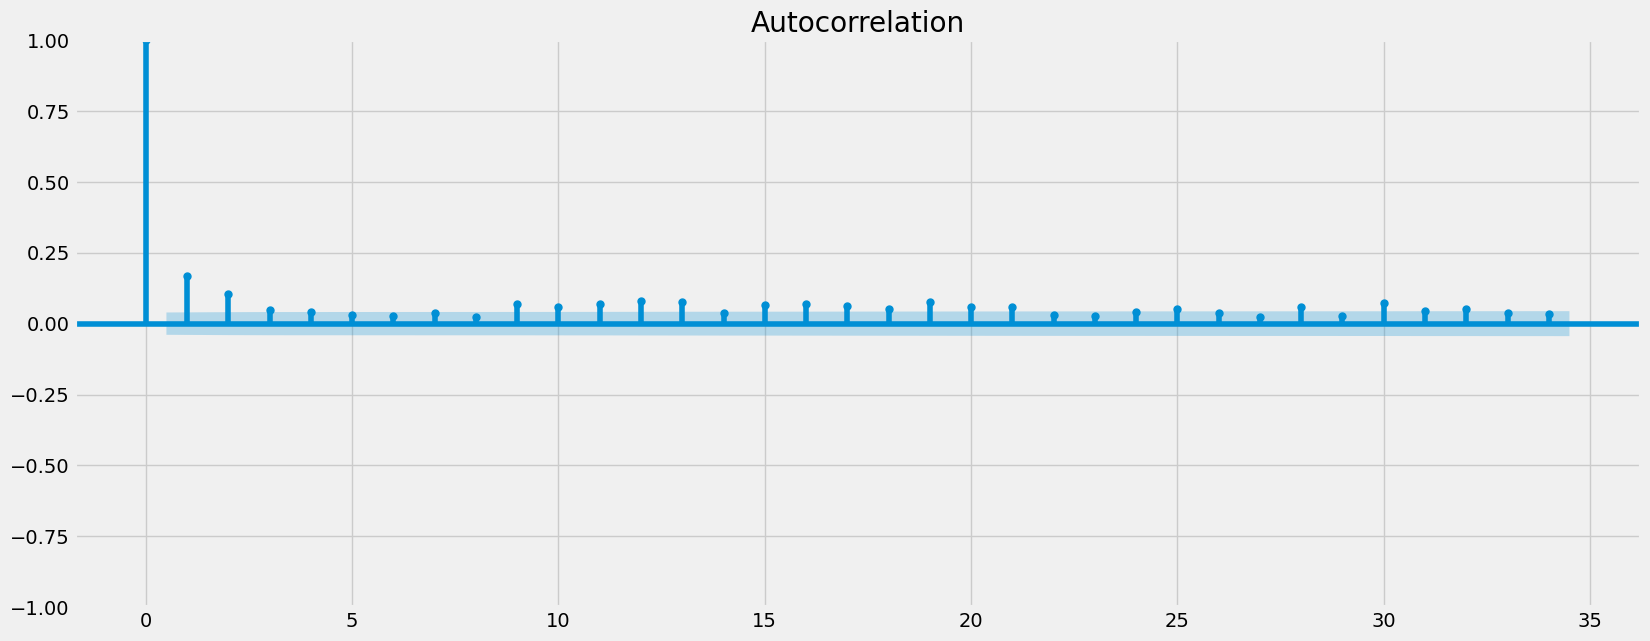

In [24]:
# Check out a plot of autocorrelations

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Here, you import the autocorrelation and partial correlation plots

plot_acf(df_sub)
plt.show()

Not 100% certain how to interpret that, BUT >10 lags are outside of the confidence interval.

So will proceed with making the data stationary use differencing

# 5. Making Stationary - Differencing

In [25]:
df_diff = df_sub - df_sub.shift(1) # The df.shift(1) function turns the observation to t-1, making the whole thing t - (t -1)

In [26]:
df_diff.dropna(inplace = True) # REmove the missing values that came about as a result of the differencing.
# Need to remove these or won't be able to run the Dickey-Fuller test.

In [27]:
df_diff.head()

,Total Runs
datetime,
1912-06-10,-196.0
1912-06-24,-20.0
1912-07-08,194.0
1912-07-15,88.0
1912-07-29,-657.0


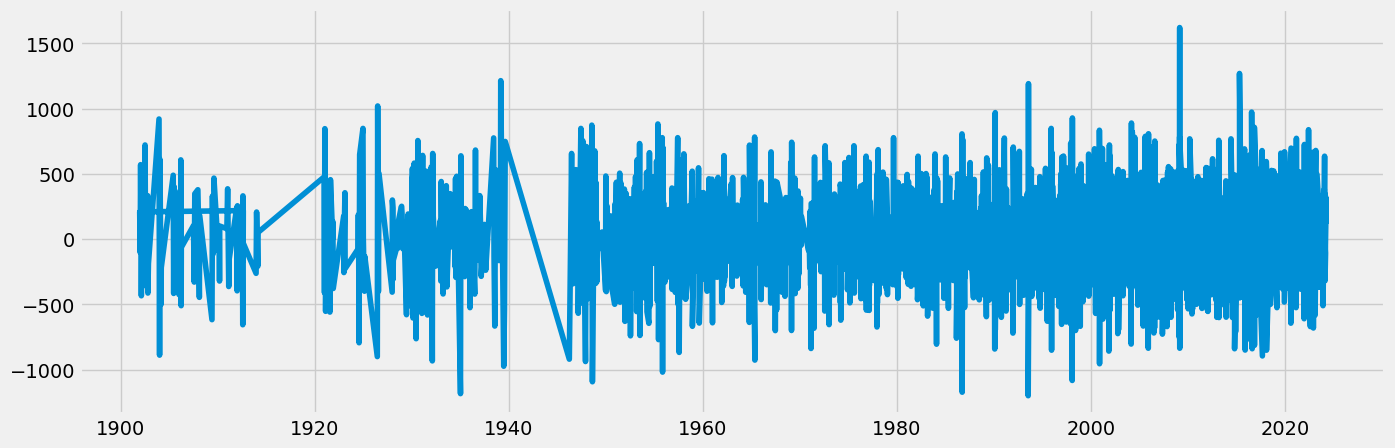

In [28]:
# Check out what the differencing did to the time-series curve

plt.figure(figsize=(15,5), dpi=100)
plt.plot(df_diff)

Looks pretty similar to before....

In [29]:
#Run Dickey-Fuller again

dickey_fuller(df_diff)

Dickey-Fuller Stationarity test:
Test Statistic                -1.578820e+01
p-value                        1.110267e-28
Number of Lags Used            2.600000e+01
Number of Observations Used    2.445000e+03
Critical Value (1%)           -3.433027e+00
Critical Value (5%)           -2.862723e+00
Critical Value (10%)          -2.567400e+00
dtype: float64


BEFORE: Test Statistic = -1.35 > Critical Value 5% = -2.86

NOW: Test Statistic = -1.57 > Critical Value 5% = -2.86

So, there is not much movement.

Second round of differencing

In [30]:
#try another round of differencing:

df_diff2 = df_diff - df_diff.shift(1) # The df.shift(1) function turns the observation to t-1, making the whole thing t - (t -1)

In [31]:
df_diff2.dropna(inplace = True) # REmove the missing values that came about as a result of the differencing.
# Need to remove these or won't be able to run the Dickey-Fuller test.

In [32]:
df_diff2.head()

,Total Runs
datetime,
1912-06-24,176.0
1912-07-08,214.0
1912-07-15,-106.0
1912-07-29,-745.0
1912-08-05,988.0


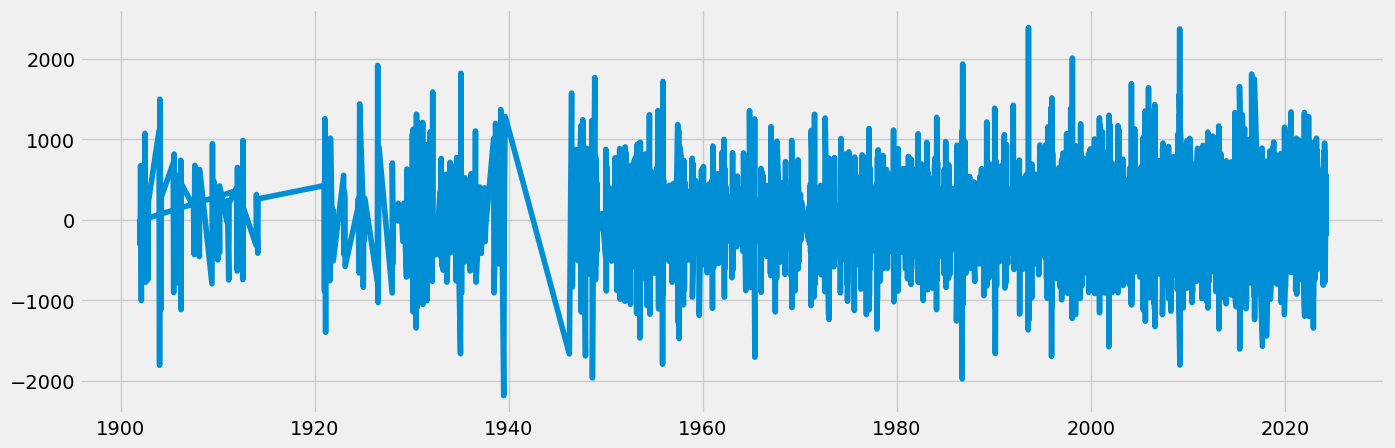

In [33]:
# Check out what the differencing did to the time-series curve

plt.figure(figsize=(15,5), dpi=100)
plt.plot(df_diff2)

Differencing appears to be creating more extreme values

In [34]:
#Run Dickey-Fuller again

dickey_fuller(df_diff2)

Dickey-Fuller Stationarity test:
Test Statistic                  -20.513467
p-value                           0.000000
Number of Lags Used              27.000000
Number of Observations Used    2443.000000
Critical Value (1%)              -3.433030
Critical Value (5%)              -2.862724
Critical Value (10%)             -2.567400
dtype: float64


Wihtout Differencing:Test Statistic = -1.35 > Critical Value 5% = -2.86

1 lot of differtencing: Test Statistic = -1.57 > Critical Value 5% = -2.86

2ns lot of differencing: Test Statistic = -20.5 < Critical Value 5% = -2.86

So should now be stationary

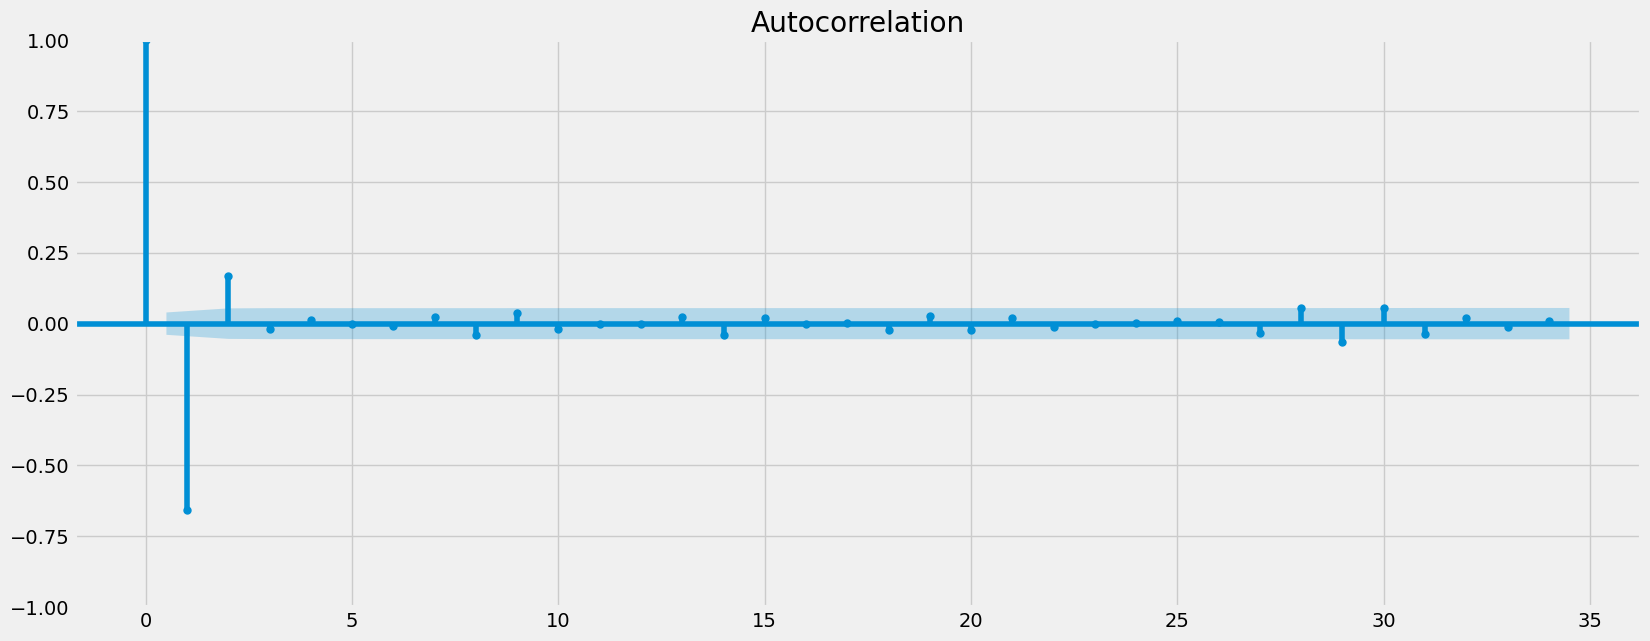

In [35]:
# Check out a plot of autocorrelations

plot_acf(df_diff2)
plt.show()

Most of the lags now within the confidence interval, so looking more stationary

# Bonus Task: Time Series Forecasting

This proved very difficult initially, and my results made little sense. I have got CoPilot to walk me through each step.

✅ Step 1: Confirm your data setup and stationarity
Before we dive into forecasting, let’s make sure your time series is properly prepared.
Checklist:
- Your time series is in a pandas Series or DataFrame with a DatetimeIndex.
- You've applied differencing twice to achieve stationarity.
- You’ve visually or statistically confirmed stationarity (e.g., using ADF test).


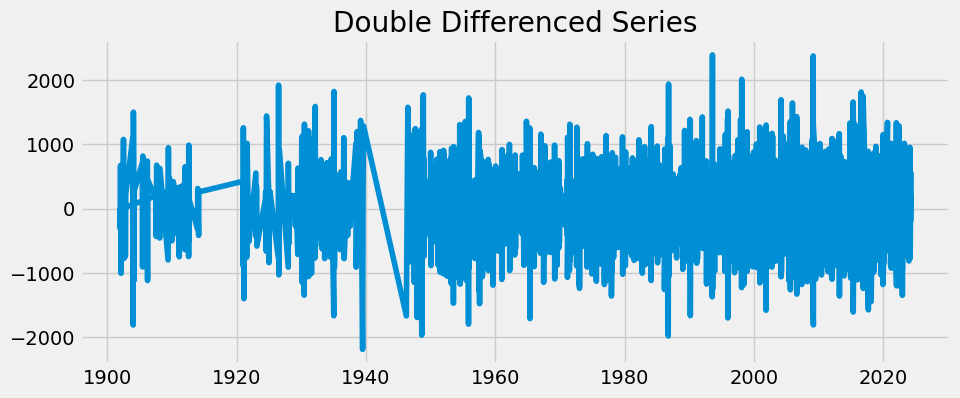

In [36]:
# Plot to confirm stationarity visually
plt.figure(figsize=(10, 4))
plt.plot(df_diff2)
plt.title("Double Differenced Series")
plt.show()


In [37]:
df_diff2.head()

,Total Runs
datetime,
1912-06-24,176.0
1912-07-08,214.0
1912-07-15,-106.0
1912-07-29,-745.0
1912-08-05,988.0


✅ Step 2: Train/Test Split and ARIMA Fitting
We’ll now:
- Split df_diff2 into training and test sets based on the year 2003.
- Fit an ARIMA model to the training data.
- Forecast the test period.
- (Later) Compare forecast vs actual.
🧠 A quick note on ARIMA:
Since your data is already differenced twice, you’ll want to set d=0 in the ARIMA model — because the differencing is already done manually.


In [38]:
# Ensure datetime index
df_diff2.index = pd.to_datetime(df_diff2.index)

# Split into train and test
train = df_diff2[df_diff2.index.year <= 2003]
test = df_diff2[df_diff2.index.year > 2003]

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (1613, 1)
Test shape: (858, 1)


In [39]:
# Check for missing values

train.isnull().sum()

,0
Total Runs,0


In [40]:
# Check for missing values

test.isnull().sum()

,0
Total Runs,0


✅ Step 2B: Fit the ARIMA model

Since you've already differenced the data twice manually, we’ll use ARIMA(order=(p, 0, q)) — with d=0.

🧠 Choosing p and q:
If you haven’t already selected p and q, we can use ACF and PACF plots to guide us. Want to do that together? Or shall we proceed with values you’ve already chosen?

Assuming you want to try p=1, q=1 for now (a common starting point), here’s how to fit the model


✅ Step 2C: Use ACF and PACF to choose p and q

ACF (Autocorrelation Function) shows how correlated the time series is with its own past values. It helps you choose the MA (moving average) order q.


PACF (Partial Autocorrelation Function) shows the correlation of the series with its lags, after removing the influence of intermediate lags. It helps you choose the AR (autoregressive) order p.


We’ll plot both to see where the significant spikes occur. A significant spike is one that crosses the blue confidence bands.





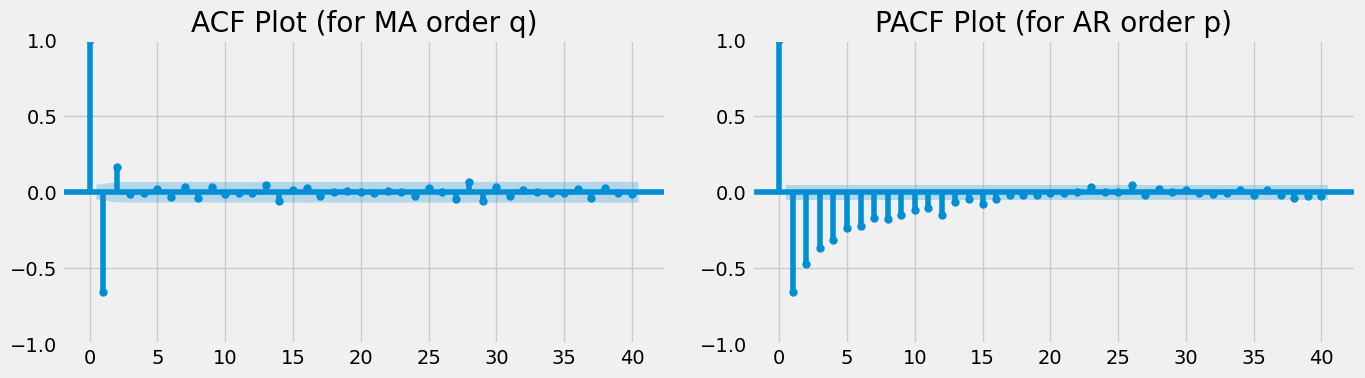

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF: helps choose q
plot_acf(train['Total Runs'], lags=40, ax=axes[0])
axes[0].set_title('ACF Plot (for MA order q)')

# PACF: helps choose p
plot_pacf(train['Total Runs'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF Plot (for AR order p)')

plt.tight_layout()
plt.show()

How to interpret:
- If ACF cuts off after lag 1, try q=1.
- If PACF cuts off after lag 2, try p=2.
- If both taper off slowly, you may need higher-order ARMA or seasonal models.


✅ Step 2D: Choose ARIMA parameters

🔍 Interpretation
- ACF: After lag 2, values drop close to zero → suggests a short MA component, likely q = 2.
- PACF: Strong spike at lag 1, then a slow upward drift → suggests a strong AR component, possibly p = 1 or p = 2.
Since PACF doesn’t cut off sharply, we’ll start conservatively with p = 1. You can later test p = 2 or higher if needed.


✅ Step 2E: Fit the ARIMA model with chosen parameters

In [42]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA with p=1, d=0, q=2 (since you've already differenced twice)
model = ARIMA(train['Total Runs'], order=(1, 0, 2))
model_fit = model.fit()

# View model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:             Total Runs   No. Observations:                 1613
Model:                 ARIMA(1, 0, 2)   Log Likelihood              -11300.254
Date:                Wed, 12 Nov 2025   AIC                          22610.507
Time:                        20:30:55   BIC                          22637.437
Sample:                             0   HQIC                         22620.503
                               - 1613                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004      0.000     -0.945      0.344      -0.001       0.000
ar.L1          0.1981      0.018     11.249      0.000       0.164       0.233
ma.L1         -1.9827      0.013   -156.312      0.0

✅ Step 3: Forecast and Compare to Test Data


We’ll now:
1. 	Forecast the same number of steps as your test set.
2. 	Align the forecast index with the test data.
3. 	Plot forecast vs actual to visually assess performance.

In [43]:
# Forecast the same number of steps as the test set
n_test = len(test)
forecast = model_fit.forecast(steps=n_test)

# Align forecast index with test data
forecast.index = test.index

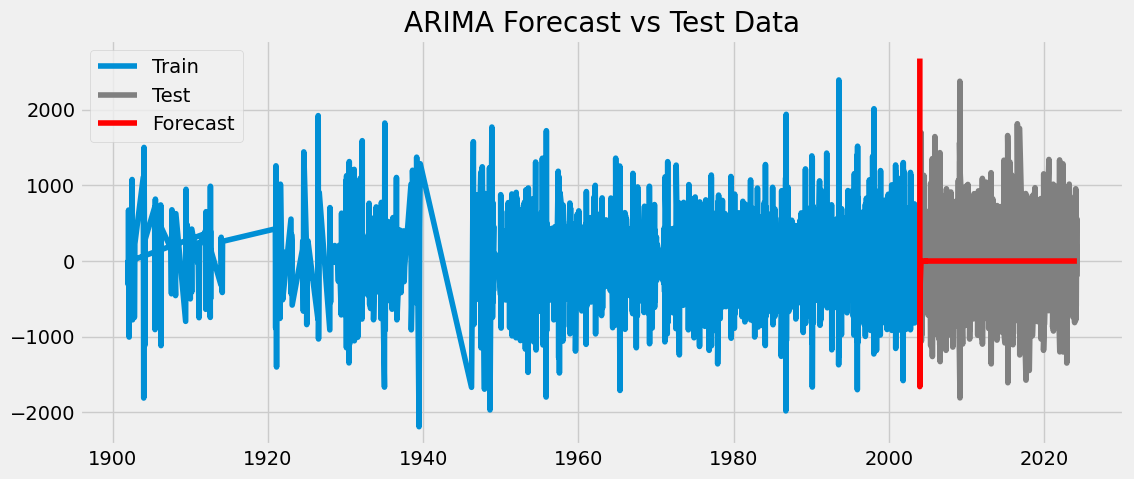

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Total Runs'], label='Train')
plt.plot(test.index, test['Total Runs'], label='Test', color='gray')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast vs Test Data')
plt.legend()
plt.show()

In [45]:
forecast.head()

,predicted_mean
datetime,
2004-01-02,2674.749185
2004-01-02,-1659.076998
2004-01-16,-328.735839
2004-02-19,-65.137229
2004-02-26,-12.906847


In [46]:
forecast.tail()

,predicted_mean
datetime,
2023-12-06,-0.0004
2024-02-02,-0.0004
2024-02-28,-0.0004
2024-03-22,-0.0004
2024-03-30,-0.0004


Thanks, Sam — that pattern is a classic sign that the ARIMA model is struggling to forecast from a stationary differenced series without being re-integrated. Right now, your forecast is in the differenced scale, not the original scale of "Total Runs." That’s why the values are swinging and collapsing toward zero.


✅ Step 4: Invert Differencing to Return to Original Scale


Since you applied two rounds of differencing, we need to integrate twice to reconstruct the forecast in the original units.
🧠 What this means:
- First, we cumulatively sum the forecast to undo the second differencing.
- Then, we cumulatively sum again and add back the last known value from the original series to anchor it


Inverting differencing

In [48]:
# First integration (undo second differencing)
forecast_level1 = forecast.cumsum()

# Second integration (undo first differencing)
forecast_level2 = forecast_level1.cumsum()

# Add back the last known value from the original series before the forecast starts
last_original_value = df_sub.loc[train.index[-1], 'Total Runs']
forecast_final = forecast_level2 + last_original_value

Plot forecast in original scal

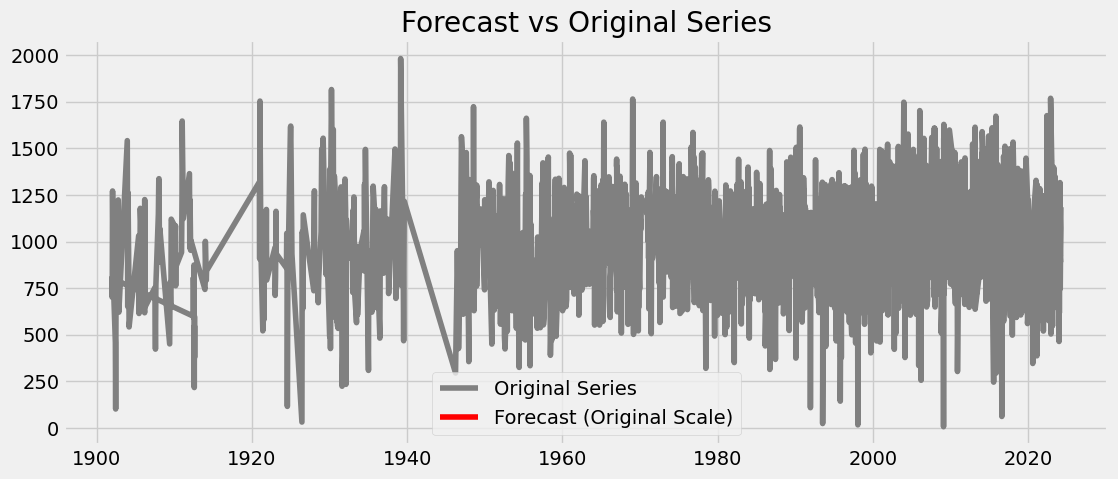

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(df_sub.index, df_sub['Total Runs'], label='Original Series', color='gray')
plt.plot(forecast_final.index, forecast_final, label='Forecast (Original Scale)', color='red')
plt.title('Forecast vs Original Series')
plt.legend()
plt.show()

In [50]:
forecast_final.head()

,0
datetime,
2003-12-26,NaN
2003-12-26,NaN
2003-12-26,NaN
2004-01-02,NaN
2004-01-02,NaN


In [51]:
# Check for missing values

forecast_final.isnull().sum()

np.int64(861)

🔍 What’s likely going wrong

When we do:
forecast_level2 = forecast_level1.cumsum()
forecast_final = forecast_level2 + last_original_value


…it assumes that the first value of forecast_level1 is a valid number. But if the forecast itself starts with a large negative swing (like -1659), the cumulative sums can go unstable — especially if the differenced series had a lot of volatility.
Also, we need to be careful about which values we add back. Since you did two rounds of differencing, we need two anchor values from df_sub to reconstruct the original scale.


✅ Let’s fix it step by step
We’ll now:
- Use the last two values from the original series (df_sub) before the forecast starts.
- Rebuild the forecast using those anchors.


Yes — that’s a crucial insight, Sam. If your  contains duplicate timestamps, many time series operations (like , , and ARIMA forecasting alignment) can misbehave or silently fail. Let’s fix this cleanly

✅ Step 5: Resolve Non-Unique Timestamps

🧪 Step 5A: Check for duplicate


In [54]:
# Check for duplicate timestamps
duplicates = df_sub.index.duplicated()
print(f"Number of duplicate timestamps: {duplicates.sum()}")

Number of duplicate timestamps: 184


Option 2: Make timestamps unique by adding a small offse

In [55]:
# Add microseconds to make timestamps unique
df_sub_clean = df_sub.copy()
df_sub_clean.index = pd.to_datetime(df_sub_clean.index) + pd.to_timedelta(df_sub_clean.groupby(df_sub.index).cumcount(), unit='us')

In [56]:
# Check for duplicate timestamps
duplicates = df_sub_clean.index.duplicated()
print(f"Number of duplicate timestamps: {duplicates.sum()}")

Number of duplicate timestamps: 0


✅ Step 6: Rebuild Forecast in Original Scale

We’ll use the last two values from df_sub_clean before the forecast starts to anchor the reconstruction.

🧪 Step-by-step code


In [57]:
# Step 1: Get the last two values before the forecast starts
last_value = df_sub_clean.loc[train.index[-1], 'Total Runs']
second_last_value = df_sub_clean.loc[train.index[-2], 'Total Runs']

# Step 2: First integration (undo second differencing)
forecast_level1 = forecast.cumsum()

# Step 3: Second integration (undo first differencing)
forecast_level2 = pd.Series(index=forecast.index, dtype='float64')
forecast_level2.iloc[0] = forecast_level1.iloc[0] + (last_value - second_last_value)

for t in range(1, len(forecast)):
    forecast_level2.iloc[t] = forecast_level2.iloc[t-1] + forecast_level1.iloc[t]

# Step 4: Add back the second_last_value to return to original scale
forecast_final = forecast_level2 + second_last_value

✅ Step 7: Plot Forecast vs Original Series

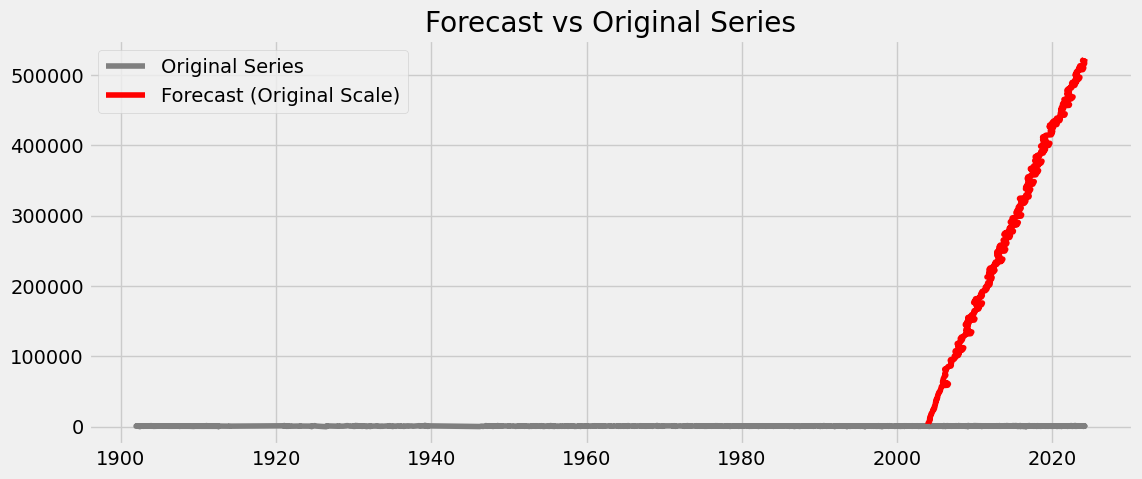

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(df_sub_clean.index, df_sub_clean['Total Runs'], label='Original Series', color='gray')
plt.plot(forecast_final.index, forecast_final, label='Forecast (Original Scale)', color='red')
plt.title('Forecast vs Original Series')
plt.legend()
plt.show()

In [59]:
forecast_final.head()

,0
datetime,
2004-01-02,3981.749185
2004-01-02,4997.421372
2004-01-16,5684.357719
2004-02-19,6306.156837
2004-02-26,6915.049109


In [61]:
forecast_final.tail()

,0
datetime,
2023-12-06,521013.357011
2024-02-02,521618.720008
2024-02-28,522224.082606
2024-03-22,522829.444803
2024-03-30,523434.806601


In [63]:
#Average of 'Total Runs' in df_sub for comparison

average_total_runs = df_sub['Total Runs'].mean()


In [64]:
average_total_runs

np.float64(996.6805499393449)

Thanks for that detail, Sam — it’s a clear sign that the inversion logic is overcompensating, likely due to how the cumulative sums are anchored. Let’s fix this precisely.

🔍 What’s happening
Your forecast is in the twice-differenced scale, so when we cumulatively sum twice, we’re essentially compounding the forecast errors. If the first forecast value is large (like 2674), the cumulative sum explodes — especially if the anchor values are misaligned.


✅ Fixing with a safer inversion strategy

Instead of manually summing and anchoring, we’ll use the original series to reconstruct the forecast step-by-step, starting from the last known values.
🧪 Step-by-step fix



In [65]:
# Get the last two original values before the forecast starts
y_tm2 = df_sub_clean.loc[train.index[-2], 'Total Runs']
y_tm1 = df_sub_clean.loc[train.index[-1], 'Total Runs']

# Create a new Series to hold the reconstructed forecast
forecast_reconstructed = pd.Series(index=forecast.index, dtype='float64')

# Step-by-step reconstruction
for i in range(len(forecast)):
    if i == 0:
        forecast_reconstructed.iloc[i] = forecast.iloc[i] + (y_tm1 - y_tm2) + y_tm1
    elif i == 1:
        forecast_reconstructed.iloc[i] = forecast.iloc[i] + (forecast_reconstructed.iloc[i-1] - y_tm1) + forecast_reconstructed.iloc[i-1]
    else:
        forecast_reconstructed.iloc[i] = forecast.iloc[i] + (forecast_reconstructed.iloc[i-1] - forecast_reconstructed.iloc[i-2]) + forecast_reconstructed.iloc[i-1]

✅ Plot the corrected forecast

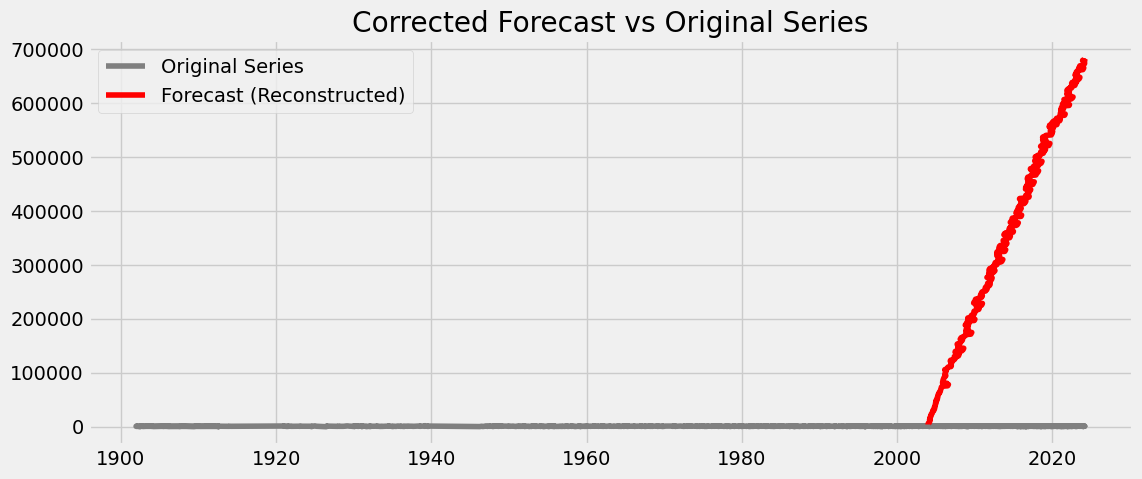

In [66]:
plt.figure(figsize=(12, 5))
plt.plot(df_sub_clean.index, df_sub_clean['Total Runs'], label='Original Series', color='gray')
plt.plot(forecast_reconstructed.index, forecast_reconstructed, label='Forecast (Reconstructed)', color='red')
plt.title('Corrected Forecast vs Original Series')
plt.legend()
plt.show()

Thanks for sticking with this, Sam — we’re nearly there. The runaway cumulative errors suggest that manual reintegration is compounding noise rather than reconstructing signal. Let’s pivot to a cleaner, more robust approach:

✅ Step 8: Let ARIMA handle differencing internally

Instead of manually differencing the data and trying to reintegrate forecasts, we’ll let the ARIMA model handle differencing via its d parameter. This way:
- You pass in the original series (df_sub_clean['Total Runs'])
- Set order=(p, d, q) with d=2 (since you confirmed stationarity after two differences)
- Forecasts will be returned in the original scale — no reintegration needed

🧪 Step-by-step code


In [67]:
from statsmodels.tsa.arima.model import ARIMA

# Split original data
train_orig = df_sub_clean[df_sub_clean.index.year <= 2003]
test_orig = df_sub_clean[df_sub_clean.index.year > 2003]

# Fit ARIMA directly on original series, letting it handle differencing
model = ARIMA(train_orig['Total Runs'], order=(1, 2, 2))
model_fit = model.fit()

# Forecast same number of steps as test set
forecast = model_fit.forecast(steps=len(test_orig))
forecast.index = test_orig.index

🧪 Plot forecast vs actual

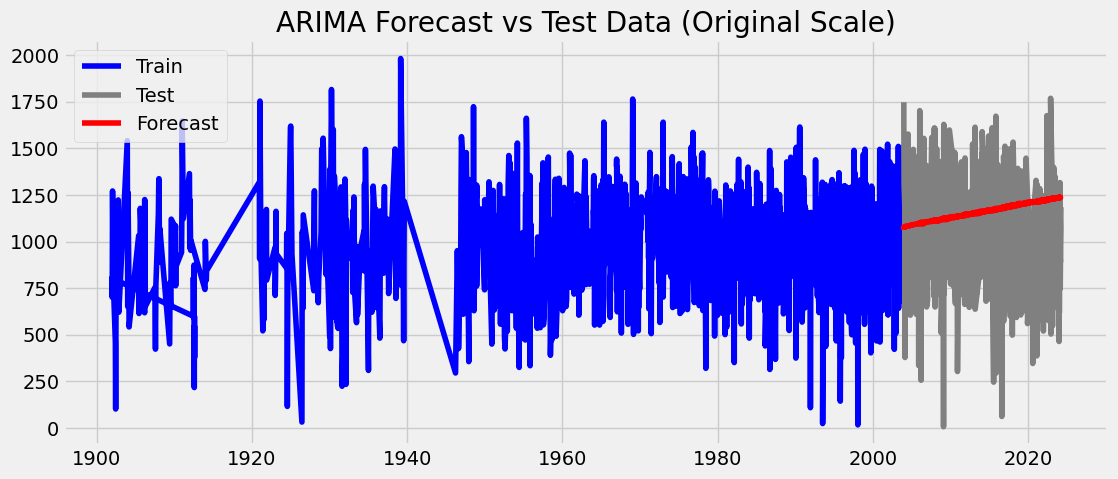

In [68]:
plt.figure(figsize=(12, 5))
plt.plot(train_orig.index, train_orig['Total Runs'], label='Train', color='blue')
plt.plot(test_orig.index, test_orig['Total Runs'], label='Test', color='gray')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast vs Test Data (Original Scale)')
plt.legend()
plt.show()

✅ Step 9: Add Confidence Intervals to Forecast Plot

Instead of using .forecast(), we’ll use .get_forecast() which returns both the predicted mean and the confidence intervals

🧪 Updated code to get forecast with interval

In [69]:
# Get forecast with confidence intervals
forecast_obj = model_fit.get_forecast(steps=len(test_orig))
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Align index
forecast_mean.index = test_orig.index
conf_int.index = test_orig.index

🧪 Plot with shaded error bands



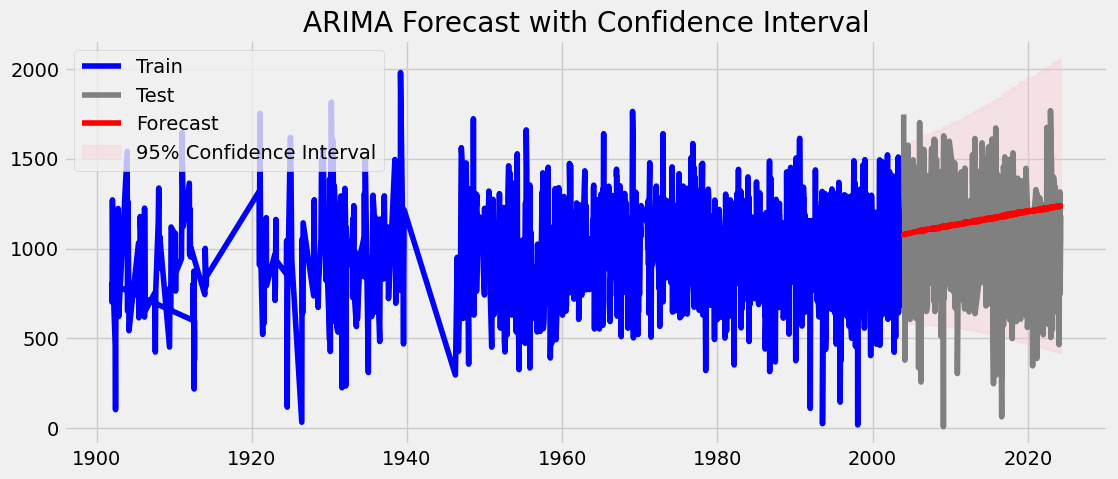

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(train_orig.index, train_orig['Total Runs'], label='Train', color='blue')
plt.plot(test_orig.index, test_orig['Total Runs'], label='Test', color='gray')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')

# Add shaded confidence interval
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],  # lower bound
                 conf_int.iloc[:, 1],  # upper bound
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('ARIMA Forecast with Confidence Interval')
plt.legend()
plt.show()